In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#data splitting
from sklearn.model_selection import train_test_split

#preprocessing
from sklearn.preprocessing import StandardScaler

#models
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#evalution
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,
                              precision_score,recall_score,f1_score)


In [107]:
df = pd.read_csv(r"C:\Users\bahug\Downloads\tech.csv")
print(df.head())
print("shape")
print(df.shape)

print("describe")
print(df.describe())

print("info")
print(df.info())

print("isnull")
print(df.isnull().sum())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [108]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [109]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [110]:
df.duplicated().sum()

np.int64(0)

In [111]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [112]:
df = df.dropna()
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df["TotalCharges"].dtype


dtype('float64')

In [113]:
df=df.drop(["customerID"],axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

EDA(exploratory data analysis)

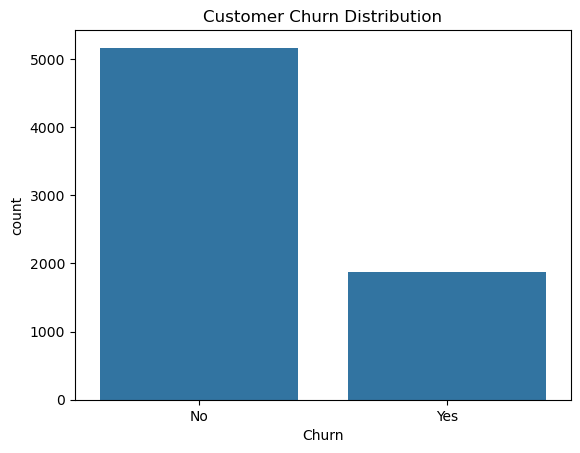

In [64]:
#create first graph
sns.countplot(x="Churn",data=df)
plt.title("Customer Churn Distribution")
plt.show()

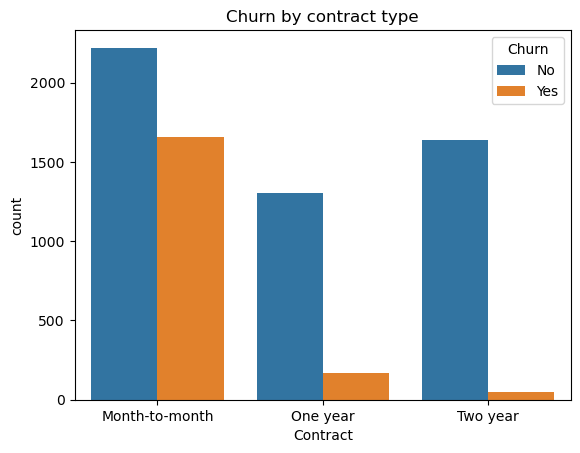

In [65]:
#churn vs contract
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Churn by contract type")
plt.show()

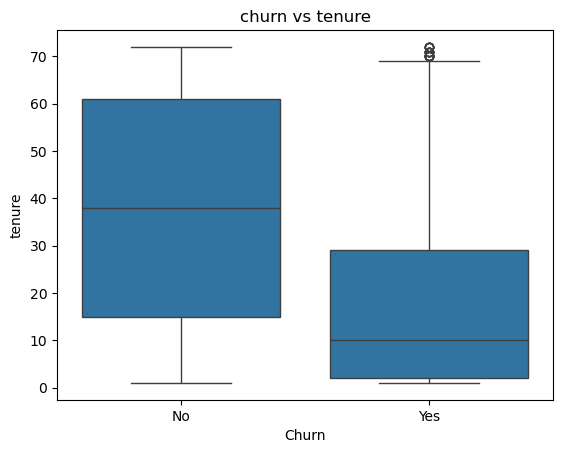

In [66]:
#churn vs tenure
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("churn vs tenure")
plt.show()

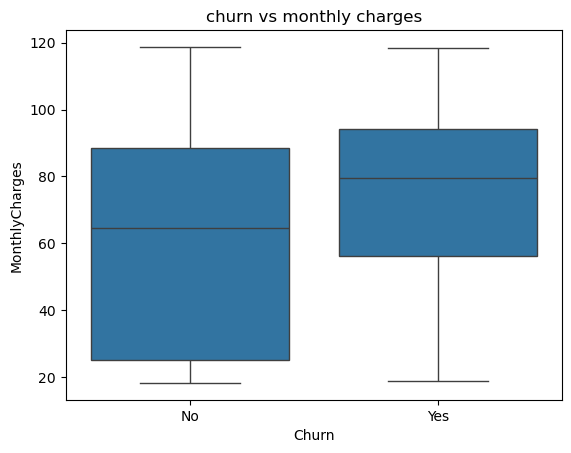

In [67]:
#churn vs monthly charges
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("churn vs monthly charges")
plt.show()

In [68]:
pd.crosstab(df["Contract"],
            df["Churn"],
             normalize=True)*100

Churn,No,Yes
Contract,,
Month-to-month,31.569966,23.535267
One year,18.572241,2.360637
Two year,23.279295,0.682594


PREPROCESSING

In [69]:
#Separate target from features
data=df.copy()
x=data.drop("Churn",axis=1)

#Convert the target
y=df["Churn"].map({"No":0,"Yes":1})

In [70]:

#Encode the categorical features
x=pd.get_dummies(x,drop_first=True)
print(x)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0                 0       1           29.85         29.85        False   
1                 0      34           56.95       1889.50         True   
2                 0       2           53.85        108.15         True   
3                 0      45           42.30       1840.75         True   
4                 0       2           70.70        151.65        False   
...             ...     ...             ...           ...          ...   
7038              0      24           84.80       1990.50         True   
7039              0      72          103.20       7362.90        False   
7040              0      11           29.60        346.45        False   
7041              1       4           74.40        306.60         True   
7042              0      66          105.65       6844.50         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            True           False             False   
1

In [71]:
#split the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4922, 30)
(2110, 30)
(4922,)
(2110,)


Train Logistic Regression

In [72]:
#Create the scaler
scaler= StandardScaler()
x_train_scaler=scaler.fit_transform(x_train)
x_test_scaler=scaler.fit_transform(x_test)

In [73]:
x.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [114]:
#Create the model

model_lr = LogisticRegression(max_iter = 100)
model_lr.fit(x_train_scaler,y_train)
#x_train_scaled → customer information
#y_train        → actual Churn (0 or 1)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [115]:
#Make predictions
y_predict_train = model_lr.predict(x_train_scaler)
y_predict_test = model_lr.predict(x_test_scaler)

Evaluate:

In [116]:
print("Accuracy :",accuracy_score(y_train,y_predict_train))
print("Accuracy :",accuracy_score(y_test,y_predict_test))
print("precision:",precision_score(y_test,y_predict_test))
print("recall   :",recall_score(y_test,y_predict_test))
print("f1 score :",f1_score(y_test,y_predict_test))

Accuracy : 0.8057700121901666
Accuracy : 0.8056872037914692
precision: 0.6576200417536534
recall   : 0.5614973262032086
f1 score : 0.6057692307692307


In [117]:
print("confusion matrix:")
print(confusion_matrix(y_test,y_predict_test))

confusion matrix:
[[1385  164]
 [ 246  315]]


In [87]:
print("classification report:")
print(classification_report(y_test,y_predict_test))

classification report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1549
           1       0.66      0.56      0.61       561

    accuracy                           0.81      2110
   macro avg       0.75      0.73      0.74      2110
weighted avg       0.80      0.81      0.80      2110



Decision Tree   

In [94]:
#create model and predict
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train,y_train)
y_predict_dt = model_dt.predict(x_test)

In [96]:
#Evaluate:
print("Accuracy :",accuracy_score(y_test,y_predict_dt))
print("precision:",precision_score(y_test,y_predict_dt))
print("recall   :",recall_score(y_test,y_predict_dt))
print("f1_score :",f1_score(y_test,y_predict_dt))

Accuracy : 0.704739336492891
precision: 0.44867549668874174
recall   : 0.483065953654189
f1_score : 0.4652360515021459


In [97]:
print("confusion matrix:")
print(confusion_matrix(y_test,y_predict_dt))

confusion matrix:
[[1216  333]
 [ 290  271]]


In [98]:
print("classification_report :")
print(classification_report(y_test,y_predict_dt))

classification_report :
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1549
           1       0.45      0.48      0.47       561

    accuracy                           0.70      2110
   macro avg       0.63      0.63      0.63      2110
weighted avg       0.71      0.70      0.71      2110



Random Forest 🌲🌲🌲

In [101]:
#create model and predict
model_rf = RandomForestClassifier(n_estimators = 100, random_state=42)
model_rf.fit(x_train,y_train)
y_predict_rf = model_rf.predict(x_test)

In [102]:
#Evaluate:
print("Accuracy :",accuracy_score(y_test,y_predict_rf))
print("precision:",precision_score(y_test,y_predict_rf))
print("recall   :",recall_score(y_test,y_predict_rf))
print("f1_score :",f1_score(y_test,y_predict_rf))

Accuracy : 0.785781990521327
precision: 0.6276346604215457
recall   : 0.47771836007130125
f1_score : 0.5425101214574899


In [103]:
print("confusion matrix:")
print(confusion_matrix(y_test,y_predict_rf))

confusion matrix:
[[1390  159]
 [ 293  268]]


In [104]:
print("classification_report :")
print(classification_report(y_test,y_predict_rf))

classification_report :
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.63      0.48      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



In [120]:
import joblib
#save logistic regression
joblib.dump(model_lr,"Chrun_model.pkl")
joblib.dump(scaler,"scaler.pkl")
joblib.dump(x_train.columns.tolist(),"feature_name.pkl")

['feature_name.pkl']

In [122]:
#test the save model
loaded_model = joblib.load("Chrun_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
predict = loaded_model.predict(loaded_scaler.transform(x_test))
print(predict[:10])

[0 0 0 0 0 0 0 0 0 0]


In [123]:
import os
print(os.listdir())

[' churn_analysis.ipynb', '.ipynb_checkpoints', 'Chrun_model.pkl', 'feature_name.pkl', 'IBM.csv', 'scaler.pkl']
